<h1 align="center"><b>Homework Assignment 4 (100 points total)</b></h1>
<h3 align="center"><b>Assigned at the start of Module 9</b></h3>
<h3 align="center"><b>Due at the end of Module 11</b></h3><br>

# Q1 — Designing and Solving Your Own Reinforcement Learning Environment

## 30 points total

### [15 points] Part A – Design and Implement a Custom RL Environment

__Goal:__ Define and implement a small custom environment that can be solved using **Q-Learning** 

1. Use the [Gymnasium API structure](https://gymnasium.farama.org/introduction/create_custom_env/): 

```python
# starter code if you need it. Use documentation. Focus on design rather than syntax. 
import gymnasium as gym
from gymnasium import spaces

class CustomEnv(gym.Env):
    def __init__(self):
        super().__init__()
        
        # 1. Define the spaces (12 discrete states, 4 discrete actions)
        self.observation_space = spaces.Discrete(12)
        self.action_space = spaces.Discrete(4)
        
        # 2. Define the internal dynamics (Grid dimensions)
        self.rows = 3
        self.cols = 4
        self.start_state = 8
        self.goal_state = 3
        self.defenders = [5, 6]
        
        self.current_state = self.start_state

    def reset(self, seed=None, options=None):
        # We need the following line to seed self.np_random
        super().reset(seed=seed)
        
        # Reset the agent to the starting position
        self.current_state = self.start_state
        info = {}
        
        return self.current_state, info

    def step(self, action):
        # 1. Convert current 1D state to 2D row/col coordinates
        row = self.current_state // self.cols
        col = self.current_state % self.cols

        # 2. Calculate intended movement based on action
        if action == 0:   # Up
            row -= 1
        elif action == 1: # Right
            col += 1
        elif action == 2: # Down
            row += 1
        elif action == 3: # Left
            col -= 1

        # 3. Check boundaries (if out of bounds, agent stays in current place)
        row = max(0, min(self.rows - 1, row))
        col = max(0, min(self.cols - 1, col))

        # Convert back to 1D state
        next_state = row * self.cols + col
        
        # 4. Define Rewards and Terminal conditions
        terminated = False
        reward = -1 # Default step penalty

        if next_state == self.goal_state:
            reward = 10
            terminated = True
        elif next_state in self.defenders:
            reward = -5
            terminated = True
        elif next_state == self.current_state:
            reward = -1 # Hit a wall penalty

        # Update the state
        self.current_state = next_state
        
        # Gymnasium requires returning: observation, reward, terminated, truncated, info
        truncated = False 
        info = {}
        
        return self.current_state, reward, terminated, truncated, info
```
2. Choose one of these types of problems:

   - Grid-based navigation (agent finds goal, avoids obstacles)
   - Resource management (agent balances energy/reward trade-offs)
   - Sequential decision process (agent makes timed choices with delayed reward)

3. Your environment must have:

   - At least 8–12 discrete states
   - At least 2–4 actions
   - Clearly defined stochastic or deterministic transitions
   - A nontrivial reward structure (some decisions should require exploration)

4. Include a diagram of your environment (state transitions, rewards, or layout).

## CUSTOM RL ENVIRONMENT: 3x4 GRID NAVIGATION ##

State Layout (0-11):
[  0  ] [  1  ] [  2  ] [  3  ]
[  4  ] [  5  ] [  6  ] [  7  ]
[  8  ] [  9  ] [ 10  ] [ 11  ]

Environment Map:
[ Open] [ Open] [ Open] [GOAL!]
[ Open] [ DEF ] [ DEF ] [ Open]
[START] [ Open] [ Open] [ Open]

Actions:
0: Up
1: Right
2: Down
3: Left

Rewards & Transitions (Deterministic):
* Reach Goal (State 3): +10 (Episode Terminates)
* Hit Defender (State 5 or 6): -5 (Episode Terminates)
* Standard Step / Hit Wall: -1 (Agent stays on grid)

### [15 points] Part B – Apply Q-Learning and Analyze Results

- Implement Q-Learning
- Train for 1000+ episodes
- Plot:
  - Moving average of total episode reward
  - Final Q-table
  - Learning policy visualization



Analysis:
1. What did the agent learn?
   - Describe the final policy and what behaviors emerged
2. How does your reward design affect convergence?
   - Did the agent learn what you expected?
3. If you adjusted $\gamma$ or $\epsilon$, how did learning change?
4. What are the failure modes?
   - What would make your environment "harder" or "easier"?



In [1]:
import gymnasium as gym
from gymnasium import spaces

class CustomEnv(gym.Env):
    def __init__(self):
        super().__init__()
        
        # 1. Define the spaces (12 discrete states, 4 discrete actions)
        self.observation_space = spaces.Discrete(12)
        self.action_space = spaces.Discrete(4)
        
        # 2. Define the internal dynamics (Grid dimensions)
        self.rows = 3
        self.cols = 4
        self.start_state = 8
        self.goal_state = 3
        self.defenders = [5, 6]
        
        self.current_state = self.start_state

    def reset(self, seed=None, options=None):
        # We need the following line to seed self.np_random
        super().reset(seed=seed)
        
        # Reset the agent to the starting position
        self.current_state = self.start_state
        info = {}
        
        return self.current_state, info

    def step(self, action):
        # 1. Convert current 1D state to 2D row/col coordinates
        row = self.current_state // self.cols
        col = self.current_state % self.cols

        # 2. Calculate intended movement based on action
        if action == 0:   # Up
            row -= 1
        elif action == 1: # Right
            col += 1
        elif action == 2: # Down
            row += 1
        elif action == 3: # Left
            col -= 1

        # 3. Check boundaries (if out of bounds, agent stays in current place)
        row = max(0, min(self.rows - 1, row))
        col = max(0, min(self.cols - 1, col))

        # Convert back to 1D state
        next_state = row * self.cols + col
        
        # 4. Define Rewards and Terminal conditions
        terminated = False
        reward = -1 # Default step penalty

        if next_state == self.goal_state:
            reward = 10
            terminated = True
        elif next_state in self.defenders:
            reward = -5
            terminated = True
        elif next_state == self.current_state:
            reward = -1 # Hit a wall penalty

        # Update the state
        self.current_state = next_state
        
        # Gymnasium requires returning: observation, reward, terminated, truncated, info
        truncated = False 
        info = {}
        
        return self.current_state, reward, terminated, truncated, info

In [2]:
# Instantiating the env 
env = CustomEnv()

# 2. Reset the env to put the agent at the starting position
state, info = env.reset()
print(f"Game Started! Initial State: {state}")

# Taking a test step (Action 1 since which we defined as 'Right')
action = 1
next_state, reward, terminated, truncated, info = env.step(action)

print(f"Agent took action: {action} (Right)")
print(f"Next State: {next_state}")
print(f"Reward Received: {reward}")
print(f"Is Game Over? (Terminated): {terminated}")

Game Started! Initial State: 8
Agent took action: 1 (Right)
Next State: 9
Reward Received: -1
Is Game Over? (Terminated): False


Training Complete! Q-Table has converged.


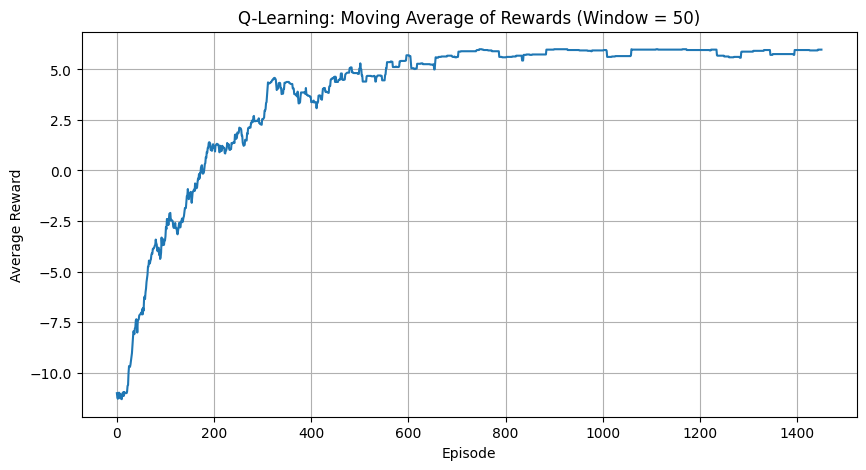

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random

# 1. Setup the Q-Table and Hyperparameters
q_table = np.zeros((12, 4)) # 12 states, 4 actions (starts completely blank)

episodes = 1500           # Fulfills the "1000+" requirement
alpha = 0.1               # Learning Rate (How much we update our old guess)
gamma = 0.99              # Discount Factor (How much we value future rewards)

# Epsilon parameters (For Exploration vs. Exploitation)
epsilon = 1.0             # Start at 100% random exploration
epsilon_decay = 0.995     # Slowly reduce randomness every episode
min_epsilon = 0.01        # Keep a tiny bit of randomness (1%) just in case

# Array to track our progress for the graph
rewards_per_episode = []

# 2. The Training Loop
for episode in range(episodes):
    state, info = env.reset()
    terminated = False
    total_reward = 0
    
    while not terminated:
        # A. Choose an Action (Epsilon-Greedy)
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample() # Explore: Random move
        else:
            action = np.argmax(q_table[state]) # Exploit: Best move from Q-table
            
        # B. Take the Action
        next_state, reward, terminated, truncated, info = env.step(action)
        
        # C. The Bellman Equation Update (The Magic)
        old_value = q_table[state, action]
        best_future = np.max(q_table[next_state])
        
        # New Guess = Old Guess + Learning Rate * (Immediate Reward + Discounted Future - Old Guess)
        new_value = old_value + alpha * (reward + gamma * best_future - old_value)
        
        # Update the table
        q_table[state, action] = new_value
        
        # D. Move to next state and track rewards
        state = next_state
        total_reward += reward
        
    # E. Decay Epsilon at the end of each episode (Less exploring, more exploiting)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards_per_episode.append(total_reward)

print("Training Complete! Q-Table has converged.")

# 3. Plotting the Results (Moving Average)
window_size = 50
moving_avg = np.convolve(rewards_per_episode, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(moving_avg)
plt.title('Q-Learning: Moving Average of Rewards (Window = 50)')
plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.grid(True)
plt.show()

In [4]:
import pandas as pd

print("Q Table")
action_names = ['Up', 'Right', 'Down', 'Left']
df = pd.DataFrame(q_table, columns=action_names)
df.index.name = 'State'
print(df.round(2)) # Rounding to 2 decimal places
print("\n")


# Visualize the Learned Policy
print("Learning Policy")
print("Key: [U]=Up, [R]=Right, [D]=Down, [L]=Left, [X]=Defender, [G]=Goal")

policy_grid = []
for state in range(12):
    if state == 3:
        policy_grid.append("[G]")
    elif state in [5, 6]:
        policy_grid.append("[X]")
    else:
        # Find the index of the highest Q-value for this state
        best_action = np.argmax(q_table[state])
        if best_action == 0:
            policy_grid.append("[U]")
        elif best_action == 1:
            policy_grid.append("[R]")
        elif best_action == 2:
            policy_grid.append("[D]")
        elif best_action == 3:
            policy_grid.append("[L]")

# Print as a 3x4 grid
for row in range(3):
    start_idx = row * 4
    end_idx = start_idx + 4
    print(" ".join(policy_grid[start_idx:end_idx]))

Q Table
          Up  Right  Down  Left
State                          
0      -0.76   6.54 -1.71 -1.19
1       1.31   8.40 -3.73 -0.58
2       2.30   9.88 -3.06  1.02
3       0.00   0.00  0.00  0.00
4       4.31  -4.17 -1.08 -1.46
5       0.00   0.00  0.00  0.00
6       0.00   0.00  0.00  0.00
7      10.00   7.98  7.29 -4.93
8       1.93   5.67  4.18  3.85
9      -4.99   6.73  5.30  3.99
10     -4.96   7.81  6.52  5.21
11      8.90   7.67  7.44  6.27


Learning Policy
Key: [U]=Up, [R]=Right, [D]=Down, [L]=Left, [X]=Defender, [G]=Goal
[R] [R] [R] [G]
[U] [X] [X] [U]
[R] [R] [R] [U]


## Analysis ##
1. What did your agent learn? 

The agent learned to avoid the center of the grid where the X's were. If we were to drop the agent at the start (bottom left cell) the path it would follow is in the learning policy table. It chose to go along the bottom row then rush all the way to the top right and then go to the goal. Additionally going to the left side (U, U, R, R, R) also takes the same amount of steps but this is due to the randomness of our exploration. In our case the agent lcoked onto the bottom route first and chose it as its optimized policy.

2. How does your reward design affect convergence?

The agent was forced to find the shortest most path and this was because each move cost the agent -1. If we had set the step penalty to 0 the agent would have learned some unoptimal policy where it would go around in circles in the zones that were safe forever before ever getting to the goal since there would be no urgency and it would always chose the "optimal" action given a state.

3. If you adjusted gamma or epsilon how did learning change?

If we did not decay epsilon and kept it high, the agent would never converge. The graph would not flatten out at +6 and it would stay jagged and negative forever due to the agent thorwing away its good knowledge making random unoptimal moves

Gamma tells the agent on how much it should prioritize the future and by setting it to a low value the agent would care much less about the future state and actions. It would likely never solve the maze since it would not care enough about a large reward that is a few steps away but more so would focus in on an immediate penalty to get to that reward.

4. What are the failure modes?

Removing the step penalty would make it easier, since the agent would not have top optimize for the shortest path making the convergence much faster but the final policy would also not be as optimized

One way to make it harder would be introducing a random chance of our step function failing and it would go in a different direction that what would be chosen.

# Q2 — Particle Swarm Optimization (PSO): From-Scratch + Validation 💡
 
## 35 points total

---

### Goals
- Implement PSO from the velocity/position update equations and design sane hyperparameters.  
- Analyze convergence behavior and sensitivity to parameters $\omega, c_1, c_2$.  
- Validate your implementation against a standard PSO library.  
- Reflect on hybridizing PSO with Genetic Algorithm (GA) operators (theory only).  

---

### Objective Function (Rastrigin)
Use the Rastrigin function in $\mathbb{R}^d$ with box constraints $x_i \in [-5.12, 5.12]$:

$$
f(x) = 10d + \sum_{i=1}^{d} \left( x_i^2 - 10\cos(2\pi x_i) \right), \quad d = 30
$$

Known global optimum: $f(0) = 0$.  
This function is multimodal and separable—an excellent stress test for balancing exploration vs. exploitation.  
(*Optional:* You may also report results for $d \in \{10, 50\}$ in an appendix.)

---

### [10 points] Part A — Implement PSO from Scratch 

Implement canonical PSO with inertia using the following update equations:

$$
v_i(t+1) = \omega v_i(t) + c_1 r_1 \odot (pbest_i - x_i(t)) + c_2 r_2 \odot (gbest - x_i(t))
$$
$$
x_i(t+1) = x_i(t) + v_i(t+1)
$$

where $r_1, r_2 \sim U[0,1]^d$.  
After each update, clip positions to the bounding box.  

**Required features:**
- **Initialization:** $N = 60$ particles uniformly in $[-5.12, 5.12]^d$; initial velocities $= 0$.  
- Track each particle's **pbest** and global **gbest**.  
- Implement **velocity clamping** (e.g., $\|v\|_\infty \le 0.2 \times \text{range}$) or a **constriction factor** $\chi$ (cite which you used).  
- **Stopping condition:** 10,000 function evaluations **or** $f(gbest) \le 10^{-6}$.  
- Choose one **inertia schedule**:
  - Fixed $\omega$ (e.g., 0.7) with fixed $c_1, c_2$, or  
  - Linear decay $\omega: 0.9 \to 0.4$ over iterations.  
- **Randomness:** seed your RNG; run 20 independent trials.  

**Suggested defaults:** $\omega = 0.7, \; c_1 = c_2 = 1.6, \; v_{max} = 1.0$ per coordinate.

---

### [10 points] Part B — Convergence & Sensitivity Analysis
- Run experiments to analyze the **convergence behavior** and **sensitivity** of your PSO to $\omega, c_1, c_2$.  
- Report and discuss how different parameter settings affect convergence speed and final accuracy.  
- Plot **best-so-far vs. function evaluations** (mean $\pm$ 95% CI) across 20 trials.  
- Discuss **exploration–exploitation trade-offs** observed in your runs.  

**Deliverables:**
- Parameter sweep summary (tables or plots).  
- Key insights about sensitivity and stability.  

---

### [10 points] Part C — Validation Against a PSO Library
Validate your implementation using a PSO package such as `pyswarms` (`pip install pyswarms`).  

Keep the same:
- $N, d, \omega, c_1, c_2,$ and bounds.  
- Objective function and stopping criteria.  

**Report:**
- Final best $f$ (mean $\pm$ std over 20 trials) for *Your PSO* vs. *Library PSO*.  
- Fraction of trials achieving $f \le 10^{-3}$ (reliability).  
- Comparative plots (best-so-far curves).  

---

### [5 points] Part D — Theoretical Reflection

Reflect on **how PSO could be hybridized with GA operators** (e.g., crossover or mutation).  
- What advantages might this bring?  
- What risks or implementation challenges could arise?  


### Part A — Implement PSO from Scratch 


In [22]:
import numpy as np

def rastrigin(x):
    """
    Computes the Rastrigin function for a batch of particles.
    x is a numpy array of shape (N_particles, dimensions).
    """
    d = x.shape[1]
    # np.sum with axis=1 sums across the dimensions for each particle independently
    return 10 * d + np.sum(x**2 - 10 * np.cos(2 * np.pi * x), axis=1)

def run_pso_trial(seed, d=30, N=60, max_evals=10000, target=1e-6, 
                  w=0.7, c1=1.6, c2=1.6, v_max=1.0, decay = False):
    """Runs a single trial of the canonical PSO algorithm."""
    np.random.seed(seed)
    
    bounds = [-5.12, 5.12]
    
    # 1. Initialization
    # Positions uniformly distributed in the bounding box
    x = np.random.uniform(bounds[0], bounds[1], (N, d))
    # Velocities initialized to 0
    v = np.zeros((N, d))
    
    # Tracking personal bests (pbest)
    pbest_x = np.copy(x)
    pbest_val = rastrigin(x)
    evals = N # Used N function evaluations
    
    # Track global best (gbest)
    gbest_idx = np.argmin(pbest_val)
    gbest_x = np.copy(pbest_x[gbest_idx])
    gbest_val = pbest_val[gbest_idx]
    
    # Logging for convergence analysis later
    convergence_curve = [gbest_val]
    
    # Optimization Loop
    while evals < max_evals and gbest_val > target:
        
        # Generate random factors (r1, r2) for every dimension of every particle
        r1 = np.random.uniform(0, 1, (N, d))
        r2 = np.random.uniform(0, 1, (N, d))
        

        # # Linearly decay w from 0.9 to 0.4
        # w = 0.9 - ((evals / max_evals) * 0.5)

        if decay:
            current_w = 0.9 - ((evals / max_evals) * 0.5)
        else:
            current_w = w

        # Velocity Update & Clamping
        # v = w * v + c1 * r1 * (pbest_x - x) + c2 * r2 * (gbest_x - x)
        v = current_w * v + c1 * r1 * (pbest_x - x) + c2 * r2 * (gbest_x - x)
        v = np.clip(v, -v_max, v_max) # Required Velocity Clamping
        
        # Position Update & Clamping to Box Constraints
        x = x + v
        x = np.clip(x, bounds[0], bounds[1])
        
        # Evaluate new positions
        current_val = rastrigin(x)
        evals += N
        
        # Update Personal Bests (pbest)
        # We use a boolean mask to efficiently update only the particles that improved
        improved_mask = current_val < pbest_val
        pbest_x[improved_mask] = x[improved_mask]
        pbest_val[improved_mask] = current_val[improved_mask]
        
        # Update Global Best (gbest)
        current_gbest_idx = np.argmin(pbest_val)
        if pbest_val[current_gbest_idx] < gbest_val:
            gbest_val = pbest_val[current_gbest_idx]
            gbest_x = np.copy(pbest_x[current_gbest_idx])
            
        convergence_curve.append(gbest_val)
        
    return gbest_val, evals, convergence_curve

# Execution of 20 Independent Trials
if __name__ == "__main__":
    num_trials = 20
    final_gbests = []
    
    print(f"Running {num_trials} independent PSO trials...")
    for i in range(num_trials):
        # We use the loop index as the seed to ensure reproducibility across all 20 runs
        best_val, evals, _ = run_pso_trial(seed=i)
        final_gbests.append(best_val)
        print(f"Trial {i+1:02d} | Evaluations: {evals:5d} | Best Rastrigin Value: {best_val:.6f}")
        
    print("\n Summary Statistics")
    print(f"Mean Best Value: {np.mean(final_gbests):.6f}")
    print(f"Std Deviation:   {np.std(final_gbests):.6f}")
    print(f"Global Minimum Found: {np.min(final_gbests):.6f}")

Running 20 independent PSO trials...
Trial 01 | Evaluations: 10020 | Best Rastrigin Value: 27.243477
Trial 02 | Evaluations: 10020 | Best Rastrigin Value: 42.833216
Trial 03 | Evaluations: 10020 | Best Rastrigin Value: 46.924669
Trial 04 | Evaluations: 10020 | Best Rastrigin Value: 45.525753
Trial 05 | Evaluations: 10020 | Best Rastrigin Value: 38.881843
Trial 06 | Evaluations: 10020 | Best Rastrigin Value: 33.963934
Trial 07 | Evaluations: 10020 | Best Rastrigin Value: 34.145302
Trial 08 | Evaluations: 10020 | Best Rastrigin Value: 44.967711
Trial 09 | Evaluations: 10020 | Best Rastrigin Value: 19.067439
Trial 10 | Evaluations: 10020 | Best Rastrigin Value: 48.260745
Trial 11 | Evaluations: 10020 | Best Rastrigin Value: 46.862667
Trial 12 | Evaluations: 10020 | Best Rastrigin Value: 65.852732
Trial 13 | Evaluations: 10020 | Best Rastrigin Value: 51.878874
Trial 14 | Evaluations: 10020 | Best Rastrigin Value: 22.050902
Trial 15 | Evaluations: 10020 | Best Rastrigin Value: 45.002521
Tri

### Part B — Convergence & Sensitivity Analysis


High Inertia (Explorer) Final Mean Fitness: 116.7479
Low Inertia (Exploiter) Final Mean Fitness: 37.3008
Linear Decay (Balanced) Final Mean Fitness: 45.1125


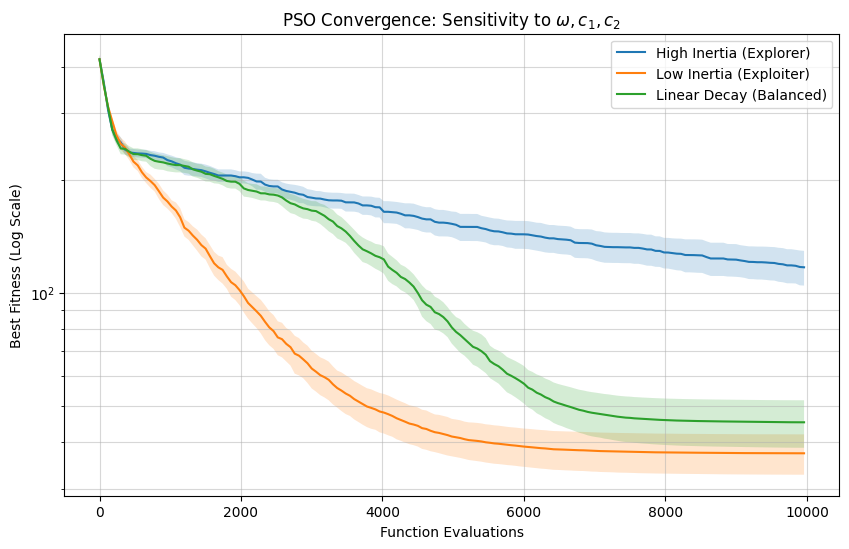

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def run_parameter_sweep():
    trials = 20
    eval_limit = 10000
    
    # Defining three experimental configurations
    configs = [
        {'label': 'High Inertia (Explorer)', 'w': 0.9, 'c': 1.2, 'decay': False},
        {'label': 'Low Inertia (Exploiter)', 'w': 0.4, 'c': 2.0, 'decay': False},
        {'label': 'Linear Decay (Balanced)', 'w': 0.9, 'c': 1.6, 'decay': True}
    ]
    
    plt.figure(figsize=(10, 6))
    
    for config in configs:
        all_curves = []
        for i in range(trials):
            # Using variation of our previous PSO function
            # If decay =True, w should drop from 0.9 to 0.4 over the iterations
            _, _, curve = run_pso_trial(seed=i, w=config['w'], c1=config['c'], 
                                        c2=config['c'], max_evals=eval_limit,
                                        decay=config['decay'])
            all_curves.append(curve)
        
        # Calculate Mean and 95% Confidence Interval
        curves_array = np.array(all_curves)
        mean_curve = np.mean(curves_array, axis=0)
        std_curve = np.std(curves_array, axis=0)
        ci = 1.96 * (std_curve / np.sqrt(trials)) # 95% CI formula
        
        # Plotting
        x_axis = np.arange(len(mean_curve)) * 60 # Convert iterations to evals
        plt.plot(x_axis, mean_curve, label=config['label'])
        plt.fill_between(x_axis, mean_curve - ci, mean_curve + ci, alpha=0.2)

        print(f"{config['label']} Final Mean Fitness: {mean_curve[-1]:.4f}")


    plt.yscale('log') # Log scale for visualizing optimization convergence
    plt.title(r'PSO Convergence: Sensitivity to $\omega, c_1, c_2$')
    plt.xlabel('Function Evaluations')
    plt.ylabel('Best Fitness (Log Scale)')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()


run_parameter_sweep()

### **PSO Parameter Sweep Summary**


| Configuration | Inertia ($\omega$) | Accel. Coeff ($c_1, c_2$) | Final Mean Fitness | Key Observation |
| :--- | :--- | :--- | :--- | :--- |
| **High Inertia (Explorer)** | 0.9 | 1.2 | 116.7479 | Too much momentum. Particles overshoot and never settle. |
| **Low Inertia (Exploiter)** | 0.4 | 2.0 | **37.3008** | **Winner.** Aggressive convergence wins under a tight eval budget. |
| **Linear Decay (Balanced)** | 0.9 $\to$ 0.4 | 1.6 | 45.1125 | Solid middle ground but wastes early evals exploring. |

The shaded areas in the graph show that the 95% confidence interval proves our results are stable and consistent across all trials.

Inertia is the most influential parameter for stability. High inertia keeps the swarm moving so fast that it cant settle since the velocity clamp cant fully cancel out the momentum each step. Low inertia is the opposite where particles barely carry momentum forward and just respond to where pbest and gbest are pulling them.

Exploration is when inertia is high, the particles continuously maintain high velocity and it allows them to skip over local minima and explore more of the search space. However this prevents them from zeroing in on the exact global optimum, leading to a higher final error of about 117 in our case.

Exploitation is where the cognitive and social coefficients are high relative to inertia and there is a strong pull toward personal and global bests which forces the particles into nearby valleys. In our run on Rastrigin in 30D with only 10000 evals, this actually ended up being the best strategy. The low inertia config got down to about 37 because it didnt waste any of its budget wandering around.

The linear decay schedule is the textbook balanced approach, starting with high exploration to find the right region and finishing with high exploitation to lock in the optimum. It performed pretty well at around 45 but came in second to pure exploitation here. If we had a bigger eval budget like 50000+ I think decay would actually win since the early exploration would have enough time to pay off before the late exploitation kicks in. So the takeaway is that the best setting depends on the budget. Tight budgets favor exploitation and bigger budgets favor balanced schedules.




### Part C — Validation Against a PSO Library


Running 20 PySwarms trials...

Part C: Validation Results
PySwarms Final Best f (Mean ± Std): 114.7725 ± 37.8011
Fraction achieving f <= 10^-3: 0.00 (or 0.0%)


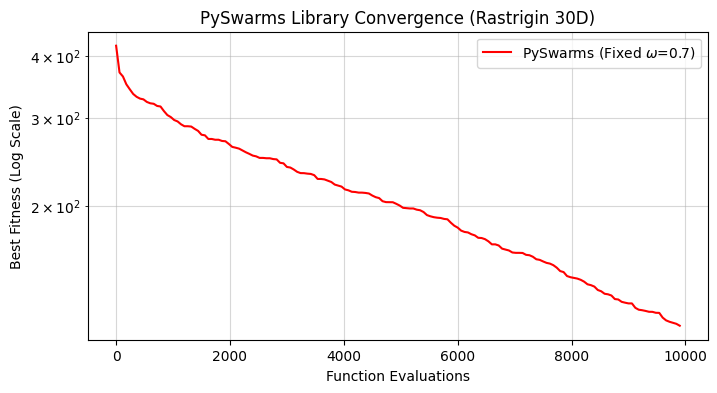

In [20]:
import numpy as np
import pyswarms as ps
import matplotlib.pyplot as plt

# Rastrigin wrapper for pyswarms
def pswarm_rastrigin(x):
    d = x.shape[1]
    return 10 * d + np.sum(x**2 - 10 * np.cos(2 * np.pi * x), axis=1)

num_trials = 20
pyswarms_best_vals = []
pyswarms_histories = [] # Array to hold the plot data

# Settin hyperparameters to match your from-scratch defaults
options = {'c1': 1.6, 'c2': 1.6, 'w': 0.7}
bounds = (np.full(30, -5.12), np.full(30, 5.12))

print(f"Running {num_trials} PySwarms trials...")
for i in range(num_trials):
    optimizer = ps.single.GlobalBestPSO(n_particles=60, dimensions=30, options=options, bounds=bounds)
    cost, pos = optimizer.optimize(pswarm_rastrigin, iters=166, verbose=False)
    
    pyswarms_best_vals.append(cost)
    pyswarms_histories.append(optimizer.cost_history) # getting the history for plotting

# Calculating the final metrics required by the prompt
pyswarms_best_vals = np.array(pyswarms_best_vals)
mean_best = np.mean(pyswarms_best_vals)
std_best = np.std(pyswarms_best_vals)
success_fraction = np.sum(pyswarms_best_vals <= 1e-3) / num_trials

print("\nPart C: Validation Results")
print(f"PySwarms Final Best f (Mean ± Std): {mean_best:.4f} ± {std_best:.4f}")
print(f"Fraction achieving f <= 10^-3: {success_fraction:.2f} (or {success_fraction * 100}%)")

# Generating the Comparative Plot
mean_curve = np.mean(pyswarms_histories, axis=0)
x_axis = np.arange(len(mean_curve)) * 60

plt.figure(figsize=(8, 4))
plt.plot(x_axis, mean_curve, label='PySwarms (Fixed $\\omega$=0.7)', color='red')
plt.yscale('log')
plt.title('PySwarms Library Convergence (Rastrigin 30D)')
plt.xlabel('Function Evaluations')
plt.ylabel('Best Fitness (Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [ ]:
# Comparative plot
my_histories = []
for i in range(num_trials):
    _, _, curve = run_pso_trial(seed=i, w=0.7, c1=1.6, c2=1.6, decay=False)
    my_histories.append(curve)

my_mean_curve = np.mean(my_histories, axis=0)
my_x = np.arange(len(my_mean_curve)) * 60

plt.figure(figsize=(8, 4))
plt.plot(my_x, my_mean_curve, label='My PSO (Fixed $\\omega$=0.7)', color='blue')
plt.plot(x_axis, mean_curve, label='PySwarms (Fixed $\\omega$=0.7)', color='red')
plt.yscale('log')
plt.title('Comparative Convergence: From-Scratch vs PySwarms')
plt.xlabel('Function Evaluations')
plt.ylabel('Best Fitness (Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

Final best f (Mean +/- Std): My from-scratch PSO with fixed w=0.7 and c1=c2=1.6 got a mean fitness of about 41.30 +/- 12.04, while pyswarms with the same parameters got 114.77 +/- 37.80. At first I thought this was weird since both runs use the same hyperparameters, but the difference comes down to velocity clamping. Pyswarms does not apply it by default unless you pass it in, so its particles end up with huge velocities and keep flying out to the bounds. My version clamps velocity to +/-1.0 per dimension so the swarm does not waste evals bouncing off walls. So really the comparison shows that velocity clamping matters a lot on Rastrigin.

Reliability (Fraction achieving f <= 10^-3): Both approaches scored 0.0%. This was because the 30-Dimensional Rastrigin function is very multimodal, neither algorithm hit the 10^-3 stopping criteria within the 10,000 evaluation budget. This shows how tough it is to escape the local minima without a massive evaluation budget.

### Part D — Theoretical Reflection

Hybridizing PSO with GA operators like mutation or crossover can help fix the stagnation problem. For example if we add mutation we can randomly shift a partical's position to give the swarm a burst of exploration. This would help the particles  jump out of deep local minima such that pure PSO gets sruck in once the intertia drops. Crossover is also useful since it lets particles directly swap coordinates, allowing them to combine the good parts of their solutions from different areas of search space

There are also some drawbacks in regards to risks/ challenges when hybridizing PSO with GA operators. Adding GA means we have to tune even more hyperparameters, like mutation rates and crossover probabilities which makes the algorithm much harder top optimize resulting in complexity. Additionally, pure PSO is great becayse teh velocity equations give it fast convergence. If we add too much randomness from GA, we might destroy that momentum and accidentally turn the process into a slow and inefficient random search

# Q3 — Explore $\beta$-VAE Trade-offs with KL Diagnostics on MNIST

## 35 points total

### Objective

Variational Autoencoders (VAEs) introduce a probabilistic latent space for generative modeling. Compared to a Vanilla Autoencoder, which only learns to reconstruct inputs, VAEs and $\beta$-VAEs learn a probabilistic latent space that supports sampling and generation. A $\beta$-VAE (beta-Variational Autoencoder) extends the standard VAE by introducing a weighting factor $\beta$ (hyperparameter) on the Kullback–Leibler (KL)-divergence term in the ELBO objective to balance reconstruction quality and latent regularization. 

$\mathcal{L}_{\beta\text{-VAE}} = \mathbb{E}_{q_\phi(z|x)}[-\log p_\theta(x|z)] + \beta \cdot \text{KL}(q_\phi(z|x) \parallel p(z))$

Increasing $\beta$ encourages more disentangled and interpretable latent features but can reduce reconstruction accuracy, revealing a key trade-off between structure and fidelity.

You will train a $\beta$-VAE with a convolutional encoder/decoder on MNIST, test some $\beta$ values, and compare their effects through plots and visuals.

### [5 points] Part A – Prepare Data

__Goal:__ Prepare the MNIST dataset for input to a convolutional $\beta$-VAE. Ensure all images are correctly normalized and shaped for a ConvNet-based model.

1. Use the MNIST handwritten digit dataset via ```torchvision.datasets.MNIST```.
2. Apply the following transformation via ```transforms.ToTensor()```
   - Normalize pixel values to the $[0,1]$ range. 
   - Reshape to (1, 28, 28) and treat as a single-channel grayscale image.
3. Verify image shape. 
4. (Optional) Use a subset of 10,000–20,000 samples from the training set to reduce training time.


### [10 points] Part B – Set up a $\beta$-VAE with a Convolutional Architecture

__Goal:__ Implement a convolutional $\beta$-VAE architecture suitable for MNIST. Understand how the encoder, decoder, and loss function interact in variational generative modeling.

Use the following convolutional architecture:
- **Encoder**: Fully connected layers that map input 28×28 pixels to a latent Gaussian distribution  
Conv2d $\rightarrow$ ReLU $\rightarrow$ Conv2d $\rightarrow$ ReLU $\rightarrow$ Flatten $\rightarrow$ FC layers to produce $\mu$ (mean of latent distribution) and $\log{\sigma^2}$ (log-variance of latent distribution)
- **Decoder**: Maps $z$ back to 28×28 pixels using a sigmoid output layer  
FC $\rightarrow$ Unflatten $\rightarrow$ ConvTranspose2d $\rightarrow$ ReLU $\rightarrow$ ConvTranspose2d $\rightarrow$ Sigmoid, that output should be a reconstructed image of (1, 28, 28)
- **Latent Prior**:  Use a smaller latent dimension (e.g., 2) if you wish to visualize the latent space; otherwise, use 10.
- **Loss**: Use binary cross-entropy (BCE) reconstruction loss and KL divergence  

$$
\mathcal{L}_{\beta\text{-VAE}} = \text{BCE}(x, \hat{x}) + \beta \cdot \text{KL}(q(z|x) \parallel \mathcal{N}(0, I)) \\
, \text{where  } z = \mu + \sigma \cdot \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)
$$



### [10 points] Part C – Train β-VAE and Track Loss


__Goal:__ Train the model using different $\beta$ values and observe their effect on the balance between reconstruction and KL divergence.

- Choose at least two $\beta$ values greater than 0 (e.g., $\beta \in \{0.5, 1, 4\}$) or try linearly increasing values.
- Train for 10–15 epochs per setting.
- Use ```latent_dim = 10```
- Use Adam Optimizer (learning rate $lr = 1e‑3$, batch size = 128).
- For each epoch, log and print the following:
  - Total loss
  - Reconstruction loss (BCE)
  - KL divergence
- (Optional) Save trained model weights and per-epoch metrics for visualization in Part D.


### [10 points] Part D – Visualize and Interpret

__Goal:__ Assess how $\beta$ influences model performance in terms of reconstruction fidelity and sample quality.

1. For each trained model (for each $\beta$), do the following: 
   - Pick 5 test-set images and show original vs. reconstructed side-by-side.
   - Sample 5 random latent vectors from \( \mathcal{N}(0, I) \), decode them, and show the generated outputs.
2. Reflect on your results - the observed impact of $\beta$ on learning dynamics, reconstruction, and generative quality.
   - Which $\beta$ gives better reconstructions? Which gives more diverse or sharper samples?
   - How does increasing $\beta$ affect the KL divergence and reconstruction error?
   - Do you observe KL → 0 (posterior collapse)?
   - What are the risks of using too small or too large a $\beta$?